# Problema 1: El Espejismo Operativo

Trabajo con el archivo delivery_logs_parcial.csv. El VP dice que Bici tiene menos reclamos que Moto y propone cambiar flota. Sospecho que es un sesgo por Zona y Distancia.


In [1]:
import pandas as pd

df = pd.read_csv('/content/delivery_logs_parcial.csv')

print(df.shape)
print(df['vehicle_type'].value_counts())


(5000, 7)
vehicle_type
Moto    3336
Bici    1664
Name: count, dtype: int64


### 1. El argumento del VP — Probabilidad condicional simple

Primero miro la proporción de reclamos dentro de cada tipo de vehículo sin condicionar nada más. Esto es lo que vio el VP.


In [2]:
p_reclamo_bici = df[df['vehicle_type']=='Bici']['claim_filed'].mean()
p_reclamo_moto = df[df['vehicle_type']=='Moto']['claim_filed'].mean()

print('P[Reclamo | Bici] =', p_reclamo_bici)
print('P[Reclamo | Moto] =', p_reclamo_moto)


P[Reclamo | Bici] = 0.18389423076923078
P[Reclamo | Moto] = 0.2511990407673861


**Análisis 1.** A nivel global el VP tiene razón en los números. Bici ~18.4% de reclamos frente a ~25.1% en moto. Esa diferencia justifica su intuición si se mira solo el vehículo, pero mezcla zonas y distancias.


### 2. Desmontando el espejismo — Probabilidad total con la zona

Veo la distribución por zona para confirmar el sesgo de operación.


In [3]:
print(pd.crosstab(df['zone'], df['vehicle_type']))

centro = df[df['zone']=='Centro']

p_reclamo_moto_centro = centro[centro['vehicle_type']=='Moto']['claim_filed'].mean()
p_reclamo_bici_centro = centro[centro['vehicle_type']=='Bici']['claim_filed'].mean()

print('P[Reclamo | Moto ∩ Centro] =', p_reclamo_moto_centro)
print('P[Reclamo | Bici ∩ Centro] =', p_reclamo_bici_centro)


vehicle_type  Bici  Moto
zone                    
Centro        1405  1095
Norte          160  1341
Sur             99   900
P[Reclamo | Moto ∩ Centro] = 0.08310502283105023
P[Reclamo | Bici ∩ Centro] = 0.12740213523131672


**Análisis 2.** Cuando aislo la zona Centro, el espejismo se invierte. La moto pasa a tener menos reclamos que la bici en la misma zona: 8.3% vs 12.7%. La ventaja aparente de la bici a nivel global no es por el vehículo, sino por dónde suele operar. La zona está confundiendo el resultado.


### 3. Auditoría inversa — Teorema de Bayes

Ahora la pregunta práctica: llega un reclamo en el Centro, ¿qué tan probable es que haya sido en moto?


In [4]:
centro = df[df['zone']=='Centro']
reclamo_centro = centro[centro['claim_filed']==1]

p_moto_dado_reclamo_centro = (reclamo_centro['vehicle_type']=='Moto').mean()

print('P[Moto | Reclamo ∩ Centro] =', p_moto_dado_reclamo_centro)
print('Reclamos en Centro:', len(reclamo_centro))
print('De ellos en Moto:', (reclamo_centro['vehicle_type']=='Moto').sum())


P[Moto | Reclamo ∩ Centro] = 0.337037037037037
Reclamos en Centro: 270
De ellos en Moto: 91


**Análisis 3.** Aunque la moto tiene menor tasa de reclamo dentro del Centro, representa alrededor del 33.7% de los reclamos que ocurren en esa zona. El cálculo de Bayes permite ver la contribución real de cada vehículo al problema.

### Conclusión del punto 1

El argumento del VP se sostiene solo en el agregado. Al condicionar por zona, la moto resulta mejor en Centro. La conclusión operativa no es cambiar flota de moto por bici de forma indiscriminada, sino revisar por qué la bici genera más reclamos en la misma zona donde debería ser más eficiente.


# Problema 2A: Pruebas de Ajuste Visual (Histograma y Gráfico Q-Q)
## El Reto Analítico
El equipo financiero quiere modelar el tiempo de entrega bajo la lluvia **(rain_flag == 1)** unando **Distribución Normal** para calcular el riesgo de superar los 30 minutos. Sin embargo, como Cientificos de Datos, ustedes saben que el tráfico urbano suele tener "colas pesadas" (eventos extremos donde un repartidor queda atrapado en un embotellamiento severo).
**Misión**: Antes de calcular cualquier probabilidad o SLA (Service Level Agreement), deben validar empíricamente si la asunción de normalidad es correcta.
1. **El Histograma**: Filtren los tiempos de entrega para los días con lluvia. Creen un histograma de estos tiempos y superpongan la curva de densidad normal teórica (pueden usar `seaborn` o `matplotlib`. Visualmente, ¿Los datos parecen seguir una campana de Gauss perfecta?.
2. **El Diagnostico Fino (Q-Q Plot)**: Generen un Gráfico Cuantil-Cuantil (Q-Q plot) utilizando `scipy.stats.probplot` o `statsmodels`.
3. **El Veredicto**: Escriban un breve párrafo interpretando las colas del gráfico Q-Q. ¿Es seguro utilizar la distribución Normal para predecir los tiempos de entrega extremos en días de lluvia, o la empresa subestima el riesgo financiero?.

## Fase 1: Histograma

Importamos librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as stm
import seaborn as sns
from scipy import stats as sts

Extraemos los datos

In [6]:
df = pd.read_csv('/content/delivery_logs_parcial.csv')
df.head()

,order_id,zone,vehicle_type,distance_km,delivery_time_min,rain_flag,claim_filed
0,ORD-20260001,Centro,Bici,2.0,32,1,0
1,ORD-20260002,Sur,Bici,1.4,16,0,0
2,ORD-20260003,Norte,Moto,4.4,39,1,0
3,ORD-20260004,Norte,Moto,6.4,47,0,1
4,ORD-20260005,Centro,Bici,2.9,32,0,1


Filtramos los datos

In [7]:
rain_days = df[df['rain_flag']==1]
rain_days.head()

,order_id,zone,vehicle_type,distance_km,delivery_time_min,rain_flag,claim_filed
0,ORD-20260001,Centro,Bici,2.0,32,1,0
2,ORD-20260003,Norte,Moto,4.4,39,1,0
7,ORD-20260008,Sur,Bici,3.1,37,1,1
11,ORD-20260012,Sur,Moto,5.9,45,1,0
13,ORD-20260014,Centro,Bici,2.0,28,1,0


Graficamos el histograma con `Seaborn`

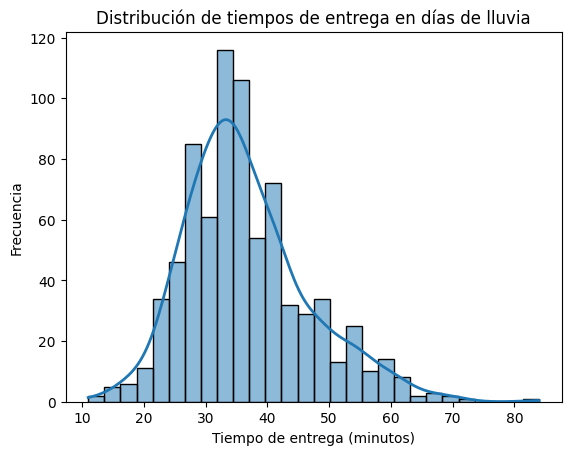

In [8]:
sns.histplot(rain_days['delivery_time_min'], kde=True, line_kws={'linewidth': 2})
plt.title('Distribución de tiempos de entrega en días de lluvia')
plt.xlabel('Tiempo de entrega (minutos)')
plt.ylabel('Frecuencia')
plt.show()

###**¿Los datos parecen seguir una campana de Gauss perfecta?**

Visualmente en el histograma vemos que los datos no siguen una campana de Gauss perfecta, debido a que la cola derecha no tiene una extención mas larga a la izquierda, sin mencionar el pico elevado de la curva KDE superpuesta, tambien vemos que la frecuencia crece, decrece y vuelve a crecer en la cola izquierda y lo mismo al revez en la cola derecha, ademas de valores atípicos con tiempo de entrega > 80 separadas de la distribución.

## Fase 2: El Diagnostico Fino (Q-Q plot)

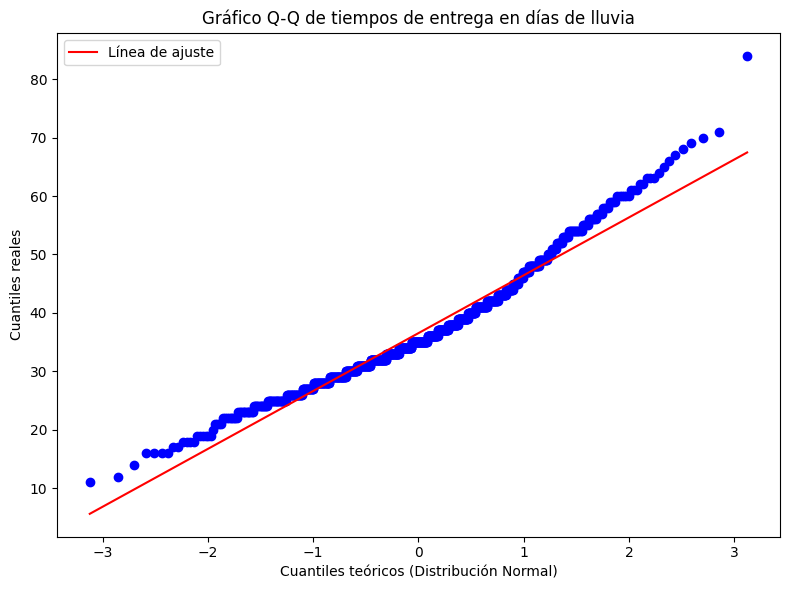

In [9]:
plt.figure(figsize=(8, 6))
sts.probplot(rain_days['delivery_time_min'], dist='norm', plot=plt)
plt.title('Gráfico Q-Q de tiempos de entrega en días de lluvia')
plt.xlabel('Cuantiles teóricos (Distribución Normal)')
plt.ylabel('Cuantiles reales')
ax = plt.gca()
line = ax.get_lines()[1]
line.set_label('Línea de ajuste')
plt.legend()
plt.tight_layout()
plt.show()

## Fase 3: Veredicto
**¿Es seguro utilizar la distribución Normal para predecir los tiempos de entrega extremos en días de lluvia, o la empresa subestima el riesgo financiero?.**

No, no es seguro. ¿por que?, en el gráfico podemos observar que en la cola derecha los puntos se desvían por encima de la linea roja teniendo incluso datos aislados en la esquina derecha el cual está muy por encima de donde debería caer. En la cola izquierda pasa similar a la derecha, los valores suben por encima de la linea, dandonos la idea de que los tiempos de entrega minimos reales son mayores a los teóricos que la normal predice. Solo en la zona central el ajuste es razonable pero solo aplican para entregas típicas.

**Por tanto, no es seguro utilizar la distribución normal para predecir los tiempos de entregas extremos en días de lluvia, la empresa subestima el riesgo financiero.**

## Problema 2B: Riesgo Estocástico y Clima

### Objetivo

Analizar el comportamiento del tiempo de entrega (`delivery_time_min`) según el clima (`rain_flag`) para evaluar el riesgo financiero de la promesa “entregas en menos de 30 minutos o el pedido es gratis”.

### 1. Parámetros de la distribución

Calculamos la media ($μ$), varianza ($σ^2$) y desviación estándar ($σ$) para los tiempos de entrega en días con clima seco (`rain_flag == 0`) y días de lluvia (`rain_flag == 1`).

In [ ]:
dry_days = df[df['rain_flag'] == 0]
rain_days_data = df[df['rain_flag'] == 1]

# Clima seco
mu_dry = dry_days['delivery_time_min'].mean()
var_dry = dry_days['delivery_time_min'].var()
sigma_dry = dry_days['delivery_time_min'].std()

# Lluvia
mu_rain = rain_days_data['delivery_time_min'].mean()
var_rain = rain_days_data['delivery_time_min'].var()
sigma_rain = rain_days_data['delivery_time_min'].std()

# Crear un DataFrame para presentar los resultados
results = pd.DataFrame({
    'Escenario': ['Clima Seco', 'Lluvia'],
    'Media (μ)': [mu_dry, mu_rain],
    'Varianza (σ²)': [var_dry, var_rain],
    'Desviación Estándar (σ)': [sigma_dry, sigma_rain]
})

display(results)

#### Interpretación de los Parámetros

- **¿Qué ocurre con el tiempo promedio cuando llueve?**
  Cuando llueve, el tiempo promedio de entrega (media) aumenta. Esto es esperable, ya que las condiciones climáticas adversas suelen ralentizar las entregas.

- **¿Qué ocurre con la varianza cuando llueve?**
  La varianza también aumenta significativamente en días de lluvia. Esto indica que los tiempos de entrega son mucho más dispersos o variables cuando el clima es adverso.

- **¿La lluvia aumenta la dispersión de los tiempos de entrega?**
  Sí, la lluvia aumenta notablemente la dispersión de los tiempos de entrega. Esto se confirma tanto por el incremento de la varianza como de la desviación estándar, sugiriendo que hay una mayor imprevisibilidad en la duración de las entregas en estas condiciones.

### 2. Riesgo teórico usando CDF Normal

Ahora, asumiendo que los tiempos de entrega con lluvia siguen una Distribución Normal, calcularemos la probabilidad teórica de que un pedido tarde más de 30 minutos cuando llueve: P[X > 30 | Lluvia].

In [ ]:
from scipy.stats import norm

# Usamos los parámetros calculados para los días de lluvia
mu_lluvia = mu_rain
sigma_lluvia = sigma_rain

# Calculamos P[X > 30 | Lluvia]
prob_mayor_30_lluvia = 1 - norm.cdf(30, loc=mu_lluvia, scale=sigma_lluvia)

print(f"La probabilidad teórica de que un pedido tarde más de 30 minutos cuando llueve (asumiendo distribución Normal) es: {prob_mayor_30_lluvia:.4f}")

### La Solución del Cuantil (SLA Dinámico)

El equipo financiero necesita establecer un nuevo tiempo límite de entrega que cubra el 95% de los escenarios lluviosos, permitiéndose regalar solo el 5% de los pedidos. Calcularemos el Cuantil 95 (Q0,95) empírico de los tiempos de entrega bajo lluvia.

In [ ]:
# Calcular el Cuantil 95 (Q0,95) empírico de los tiempos de entrega bajo lluvia
quantile_95_rain = rain_days_data['delivery_time_min'].quantile(0.95)

print(f"El Cuantil 95 (Q0,95) empírico de los tiempos de entrega en días de lluvia es: {quantile_95_rain:.2f} minutos")
print(f"Para no regalar más del 5% de los pedidos en días de lluvia, el nuevo límite de tiempo de entrega debería ser de {quantile_95_rain:.0f} minutos.")

### Nuevo Eslogan para días de tormenta

Dado que el nuevo tiempo límite de entrega para días de lluvia debería ser de aproximadamente **56 minutos** para cumplir con el objetivo del 95% de los pedidos entregados a tiempo, un posible eslogan para la App en días de tormenta podría ser:

**"Tu pedido llega en menos de 56 minutos o es gratis!"**